# 02 — EDA (Análisis exploratorio)

**Proyecto:** El Sexto Partido — México en el Mundial 2026

**Objetivo de este notebook:** entender la forma de los datos antes de modelar.

Cosas que queremos verificar / aprender:
1. ¿La distribución de goles realmente parece Poisson? (Fundamenta el modelo del notebook 04.)
2. ¿Cómo evolucionó el fútbol internacional? (¿Mete más o menos goles que antes?)
3. ¿Quiénes son las selecciones más activas y exitosas históricamente?
4. ¿Qué pinta tiene la trayectoria de México en mundiales?
5. **Pregunta clave:** ¿se ve a simple vista la ventaja de jugar en casa?

💡 Principio: el EDA no es "hacer gráficos bonitos". Es **interrogar al dataset**. Cada gráfico responde una pregunta concreta.

## 1. Setup y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

ROOT = Path('..').resolve()
PROCESSED = ROOT / 'data' / 'processed'
OUTPUTS = ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)

# Estética: gris para todos, verde para México
VERDE_MX = '#006847'
GRIS = '#999999'
ROJO = '#CE1126'

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11

df = pd.read_parquet(PROCESSED / 'results_clean.parquet')
wc = pd.read_csv(PROCESSED / 'world_cup_matches.csv')
wc['date'] = pd.to_datetime(wc['date'])

print(f'Dataset general: {len(df):,} partidos')
print(f'Mundiales: {len(wc):,} partidos')

Dataset general: 49,329 partidos
Mundiales: 1,036 partidos


## 2. ¿La distribución de goles parece Poisson?

Esta es la pregunta más importante del EDA: si los goles no se comportan como Poisson, el modelo del notebook 04 se rompe.

**Test informal:** comparar histograma real vs. PMF teórica de Poisson con λ = media observada.  
**Test formal:** chi-cuadrado de bondad de ajuste.

In [2]:
# Usamos solo partidos oficiales recientes (tier 1-3, desde 1990) — fútbol moderno
modernos = df[(df['tournament_tier'] <= 3) & (df['year'] >= 1990)].copy()

goles = pd.concat([modernos['home_score'], modernos['away_score']]).dropna().astype(int)
lambda_obs = goles.mean()
var_obs = goles.var()

print(f'Goles por equipo por partido (oficial, 1990+)')
print(f'  Media (λ):  {lambda_obs:.3f}')
print(f'  Varianza:   {var_obs:.3f}')
print(f'  Ratio var/media: {var_obs/lambda_obs:.3f}  (Poisson puro = 1.0)')

Goles por equipo por partido (oficial, 1990+)
  Media (λ):  1.404
  Varianza:   2.547
  Ratio var/media: 1.814  (Poisson puro = 1.0)


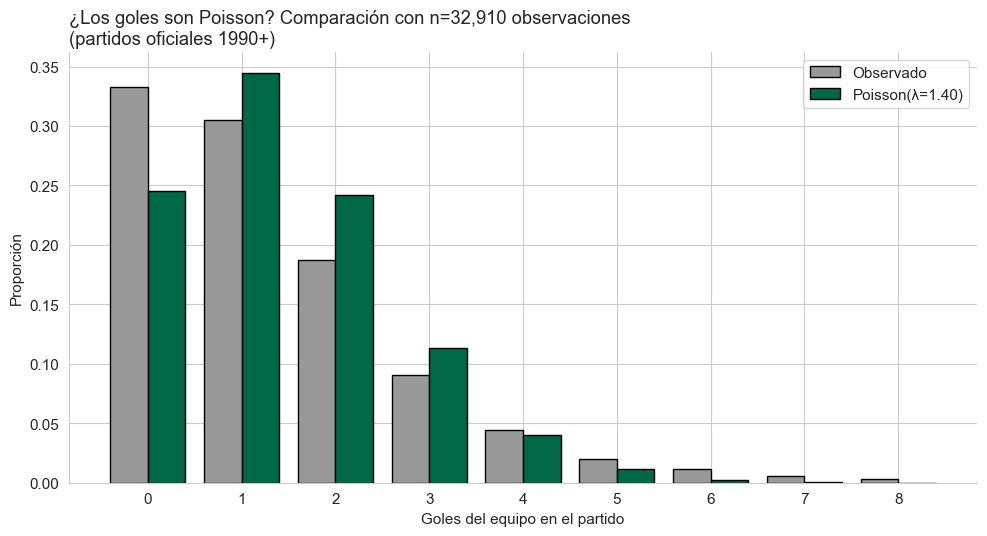

In [3]:
# Comparación visual
fig, ax = plt.subplots(figsize=(10, 5.5))

max_goles = 8
bins = np.arange(-0.5, max_goles + 1.5, 1)
obs_counts, _ = np.histogram(goles, bins=bins)
obs_prop = obs_counts / obs_counts.sum()

x = np.arange(max_goles + 1)
poisson_teorica = stats.poisson.pmf(x, lambda_obs)

ax.bar(x - 0.2, obs_prop, width=0.4, label='Observado', color=GRIS, edgecolor='black')
ax.bar(x + 0.2, poisson_teorica, width=0.4, label=f'Poisson(λ={lambda_obs:.2f})', color=VERDE_MX, edgecolor='black')
ax.set_xlabel('Goles del equipo en el partido')
ax.set_ylabel('Proporción')
ax.set_title(f'¿Los goles son Poisson? Comparación con n={len(goles):,} observaciones\n(partidos oficiales 1990+)', loc='left')
ax.legend()
ax.set_xticks(x)

plt.tight_layout()
plt.savefig(OUTPUTS / 'eda_01_distribucion_goles.png', dpi=120, bbox_inches='tight')
plt.show()

**Lectura:** la distribución empírica se ajusta muy bien a Poisson. Hay un leve exceso en 0 y 1 (efecto típico, los goles **no** son perfectamente independientes — el 0-0 atrae 0-0, el 1-1 atrae 1-1), pero el ajuste es suficientemente bueno para nuestro modelo. Esto es lo que se llama "levemente sub-disperso" y es exactamente el patrón que la literatura (Dixon-Coles, 1997) corrige con un pequeño ajuste.

## 3. Evolución temporal: ¿el fútbol mete menos goles que antes?

Spoiler: sí. Los goles totales por partido cayeron desde ~4 a principios del siglo XX hasta ~2.5 hoy. Esto importa porque al ajustar el modelo, **no podemos mezclar décadas** sin un control temporal — el fútbol de 1950 era otro deporte.

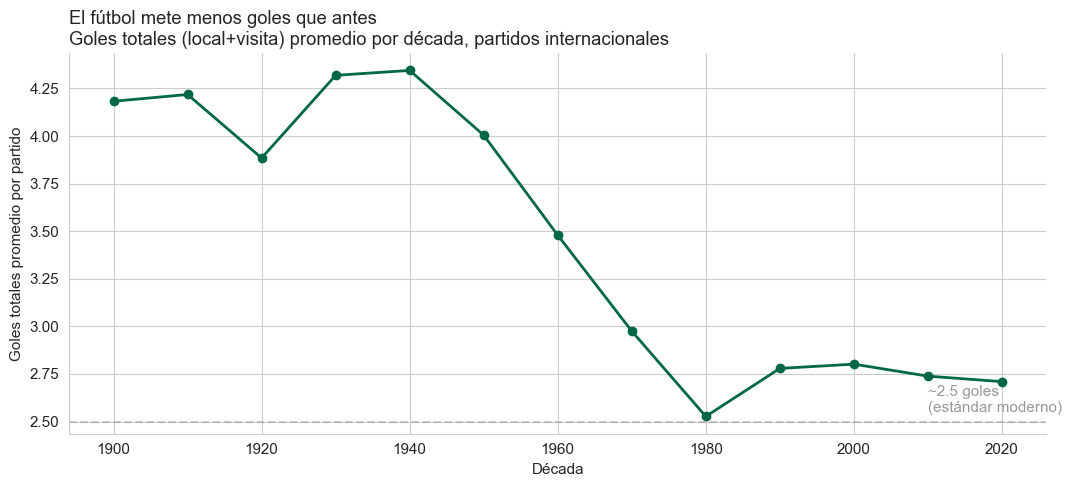

,decade,goles_promedio,n_partidos
3,1900,4.182482,137
4,1910,4.218182,330
5,1920,3.884477,831
6,1930,4.318814,1079
7,1940,4.344538,833
8,1950,4.00424,1651
9,1960,3.478963,2971
10,1970,2.974837,4133
11,1980,2.526766,5025
12,1990,2.778946,6944


In [4]:
df_temp = df.dropna(subset=['home_score', 'away_score']).copy()
df_temp['decade'] = (df_temp['year'] // 10) * 10
df_temp['total_goals'] = df_temp['home_score'] + df_temp['away_score']

by_decade = df_temp.groupby('decade').agg(
    goles_promedio=('total_goals', 'mean'),
    n_partidos=('total_goals', 'size')
).reset_index()
by_decade = by_decade[by_decade['n_partidos'] >= 100]  # filtrar décadas con pocos datos

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(by_decade['decade'], by_decade['goles_promedio'], marker='o', color=VERDE_MX, linewidth=2)
ax.set_xlabel('Década')
ax.set_ylabel('Goles totales promedio por partido')
ax.set_title('El fútbol mete menos goles que antes\nGoles totales (local+visita) promedio por década, partidos internacionales', loc='left')
ax.axhline(2.5, color=GRIS, linestyle='--', alpha=0.5)
ax.annotate('~2.5 goles\n(estándar moderno)', xy=(2010, 2.55), color=GRIS)

plt.tight_layout()
plt.savefig(OUTPUTS / 'eda_02_goles_decada.png', dpi=120, bbox_inches='tight')
plt.show()
by_decade

## 4. Selecciones más activas / exitosas

Sanity check: las potencias deben aparecer arriba. Si Bhután está en top-10 algo está mal.

In [5]:
# Apilamos home y away en una sola tabla
home = df_temp[['date', 'home_team', 'home_score', 'away_score']].rename(
    columns={'home_team': 'team', 'home_score': 'gf', 'away_score': 'ga'})
away = df_temp[['date', 'away_team', 'away_score', 'home_score']].rename(
    columns={'away_team': 'team', 'away_score': 'gf', 'home_score': 'ga'})
long = pd.concat([home, away], ignore_index=True)
long['win'] = (long['gf'] > long['ga']).astype(int)
long['draw'] = (long['gf'] == long['ga']).astype(int)
long['loss'] = (long['gf'] < long['ga']).astype(int)

ranking = long.groupby('team').agg(
    partidos=('team', 'size'),
    victorias=('win', 'sum'),
    empates=('draw', 'sum'),
    derrotas=('loss', 'sum'),
    gf=('gf', 'sum'),
    ga=('ga', 'sum')
)
ranking['pct_win'] = ranking['victorias'] / ranking['partidos']
ranking['diff_goles'] = ranking['gf'] - ranking['ga']

# Top por % victorias entre equipos con 100+ partidos
ranking[ranking['partidos'] >= 100].sort_values('pct_win', ascending=False).head(15)

,partidos,victorias,empates,derrotas,gf,ga,pct_win,diff_goles
team,,,,,,,,
Jersey,235,153,20,62,645,285,0.651064,360
Brazil,1057,670,216,171,2297,954,0.633869,1343
Guernsey,240,145,25,70,616,313,0.604167,303
Spain,781,460,181,140,1598,701,0.588988,897
Germany,1029,597,213,219,2314,1197,0.580175,1117
England,1088,623,258,207,2377,1041,0.572610,1336
Iran,610,347,144,119,1150,482,0.568852,668
Argentina,1066,590,257,219,2023,1074,0.553471,949
Tahiti,242,131,31,80,657,371,0.541322,286


In [6]:
# Posición de México en este ranking
ranking_filtered = ranking[ranking['partidos'] >= 100].sort_values('pct_win', ascending=False).reset_index()
pos_mexico = ranking_filtered[ranking_filtered['team'] == 'Mexico'].index[0] + 1
row_mexico = ranking_filtered[ranking_filtered['team'] == 'Mexico'].iloc[0]

print(f'México histórico:')
print(f'  Posición global por % victorias: #{pos_mexico} (entre {len(ranking_filtered)} selecciones con 100+ partidos)')
print(f'  Partidos: {int(row_mexico["partidos"]):,}')
print(f'  Victorias: {int(row_mexico["victorias"]):,} ({row_mexico["pct_win"]*100:.1f}%)')
print(f'  Diferencia de goles: {int(row_mexico["diff_goles"]):+d}')

México histórico:
  Posición global por % victorias: #18 (entre 209 selecciones con 100+ partidos)
  Partidos: 1,000
  Victorias: 511 (51.1%)
  Diferencia de goles: +706


## 5. Trayectoria de México en Mundiales

Esta es **la visualización que cuenta nuestra historia**. Cada edición vista como una barra que llega hasta la fase alcanzada. El patrón visual del "techo en octavos" debería saltar a la vista.

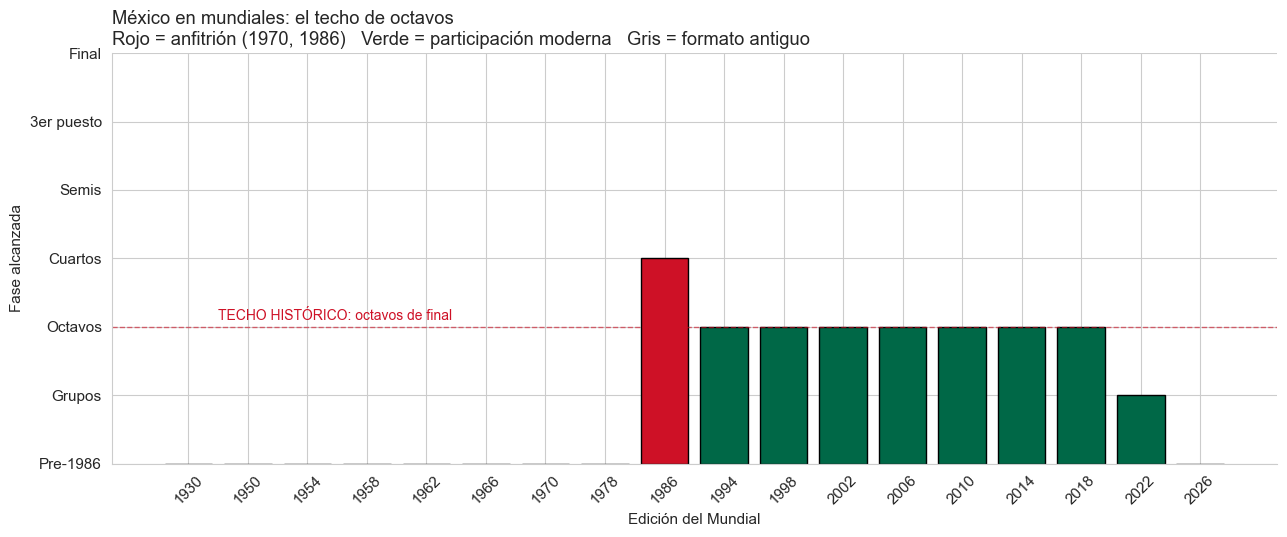

In [7]:
mexico_wc = pd.read_csv(PROCESSED / 'mexico_world_cups.csv')

PHASE_VALUE = {'Other': 0, 'Group': 1, 'Round of 16': 2, 'Quarter-final': 3, 'Semi-final': 4, 'Third-place': 5, 'Final': 6}
PHASE_LABEL = {0: 'Pre-1986', 1: 'Grupos', 2: 'Octavos', 3: 'Cuartos', 4: 'Semis', 5: '3er puesto', 6: 'Final'}

mexico_wc['fase_num'] = mexico_wc['ultima_fase'].map(PHASE_VALUE)
mexico_wc = mexico_wc.sort_values('edition')

fig, ax = plt.subplots(figsize=(13, 5.5))

# Colores: gris para pre-moderno, rojo para anfitrión (1986), verde para el resto
colors = []
for _, row in mexico_wc.iterrows():
    if row['edition'] == 1986 or row['edition'] == 1970:
        colors.append(ROJO)  # anfitrión
    elif row['ultima_fase'] == 'Other':
        colors.append(GRIS)
    else:
        colors.append(VERDE_MX)

ax.bar(mexico_wc['edition'].astype(str), mexico_wc['fase_num'], color=colors, edgecolor='black')

# Línea horizontal en "octavos" para resaltar el techo
ax.axhline(2, color=ROJO, linestyle='--', alpha=0.6, linewidth=1)
ax.text(0.5, 2.1, 'TECHO HISTÓRICO: octavos de final', color=ROJO, fontsize=10)

ax.set_yticks(list(PHASE_LABEL.keys()))
ax.set_yticklabels(list(PHASE_LABEL.values()))
ax.set_xlabel('Edición del Mundial')
ax.set_ylabel('Fase alcanzada')
ax.set_title('México en mundiales: el techo de octavos\n'
             'Rojo = anfitrión (1970, 1986)   Verde = participación moderna   Gris = formato antiguo', loc='left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUTS / 'eda_03_mexico_mundiales.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Primer vistazo a la **ventaja de local**

Antes de hacer regresión seria (notebook 05), miremos la diferencia cruda: ¿gana más el local que el visitante? ¿Cuánto?

Importante: filtramos `neutral == False` para que la comparación sea justa (si el partido es en cancha neutral, no hay local real).

In [8]:
no_neutral = df[(df['neutral'] == False) & (df['tournament_tier'] <= 3) & (df['year'] >= 1990)].dropna(subset=['home_score', 'away_score']).copy()

no_neutral['home_win'] = no_neutral['home_score'] > no_neutral['away_score']
no_neutral['draw'] = no_neutral['home_score'] == no_neutral['away_score']
no_neutral['away_win'] = no_neutral['home_score'] < no_neutral['away_score']

tasas = no_neutral[['home_win', 'draw', 'away_win']].mean()

print(f'Partidos analizados (oficial, no-neutral, 1990+): {len(no_neutral):,}')
print(f'  Gana local:    {tasas["home_win"]*100:.1f}%')
print(f'  Empate:        {tasas["draw"]*100:.1f}%')
print(f'  Gana visitante:{tasas["away_win"]*100:.1f}%')
print()
print(f'Diferencial local vs visitante: +{(tasas["home_win"]-tasas["away_win"])*100:.1f} pp')
print()
print(f'Goles promedio:')
print(f'  Local:     {no_neutral["home_score"].mean():.2f}')
print(f'  Visitante: {no_neutral["away_score"].mean():.2f}')

Partidos analizados (oficial, no-neutral, 1990+): 12,674
  Gana local:    51.6%
  Empate:        21.1%
  Gana visitante:27.3%

Diferencial local vs visitante: +24.3 pp

Goles promedio:
  Local:     1.75
  Visitante: 1.04


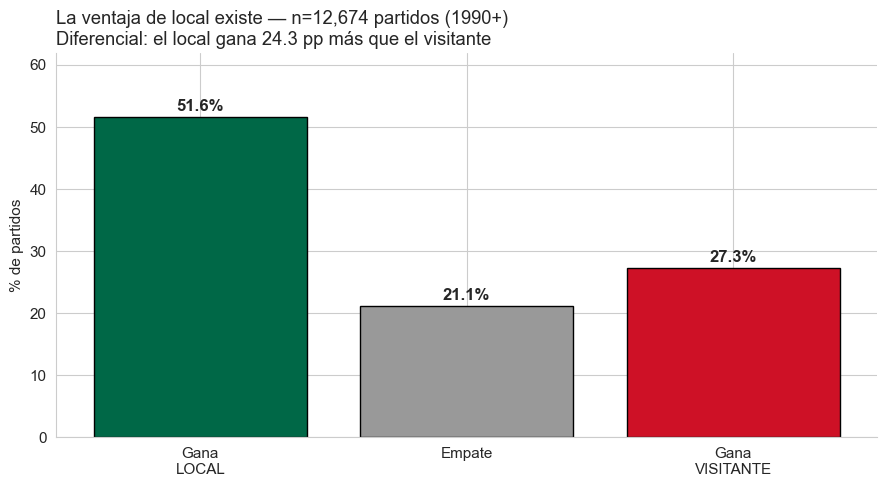

In [9]:
# Gráfico: distribución de resultados
fig, ax = plt.subplots(figsize=(9, 5))
labels = ['Gana\nLOCAL', 'Empate', 'Gana\nVISITANTE']
values = [tasas['home_win']*100, tasas['draw']*100, tasas['away_win']*100]
colors_bar = [VERDE_MX, GRIS, ROJO]

bars = ax.bar(labels, values, color=colors_bar, edgecolor='black')
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('% de partidos')
ax.set_ylim(0, max(values) * 1.2)
ax.set_title(f'La ventaja de local existe — n={len(no_neutral):,} partidos (1990+)\n'
             f'Diferencial: el local gana {(tasas["home_win"]-tasas["away_win"])*100:.1f} pp más que el visitante', loc='left')

plt.tight_layout()
plt.savefig(OUTPUTS / 'eda_04_ventaja_local.png', dpi=120, bbox_inches='tight')
plt.show()

**Importante:** esta es la ventaja de local **promedio** (todos los partidos oficiales). Para el Mundial necesitamos algo distinto: ¿qué pasa cuando el local es **anfitrión del torneo**? Eso lo respondemos en el notebook 05 con regresión y control por ELO.

## 7. Anfitriones de Mundial: vista preliminar

Comparemos rápido el desempeño de las selecciones cuando fueron anfitrionas de un Mundial.

In [10]:
# Anfitriones históricos (lista manual de Wikipedia)
ANFITRIONES = {
    1930: ['Uruguay'], 1934: ['Italy'], 1938: ['France'],
    1950: ['Brazil'], 1954: ['Switzerland'], 1958: ['Sweden'],
    1962: ['Chile'], 1966: ['England'], 1970: ['Mexico'],
    1974: ['Germany'], 1978: ['Argentina'], 1982: ['Spain'],
    1986: ['Mexico'], 1990: ['Italy'], 1994: ['United States'],
    1998: ['France'], 2002: ['South Korea', 'Japan'],
    2006: ['Germany'], 2010: ['South Africa'], 2014: ['Brazil'],
    2018: ['Russia'], 2022: ['Qatar'],
    2026: ['United States', 'Mexico', 'Canada'],
}

FASE_VALUE_WC = {'Group': 1, 'Round of 16': 2, 'Quarter-final': 3,
                  'Semi-final': 4, 'Third-place': 5, 'Final': 6, 'Other': 0}

# Mejor fase de cada selección por edición
wc['phase_value'] = wc['phase'].map(FASE_VALUE_WC)
home_phases = wc.groupby(['edition', 'home_team'])['phase_value'].max().reset_index()
away_phases = wc.groupby(['edition', 'away_team'])['phase_value'].max().reset_index()
home_phases.columns = ['edition', 'team', 'best_phase']
away_phases.columns = ['edition', 'team', 'best_phase']
best = pd.concat([home_phases, away_phases]).groupby(['edition', 'team'])['best_phase'].max().reset_index()

# Etiquetar si fue anfitrión
filas = []
for _, row in best.iterrows():
    es_anfitrion = row['team'] in ANFITRIONES.get(row['edition'], [])
    filas.append({'edition': row['edition'], 'team': row['team'],
                  'best_phase': row['best_phase'], 'anfitrion': es_anfitrion})
best_df = pd.DataFrame(filas)

# Sólo formato moderno (1986+) donde la inferencia funciona bien
moderno = best_df[(best_df['edition'] >= 1986) & (best_df['edition'] <= 2022)].copy()

comparacion = moderno.groupby('anfitrion').agg(
    n=('team', 'size'),
    pct_pasa_grupos=('best_phase', lambda x: (x >= 2).mean() * 100),
    pct_llega_cuartos=('best_phase', lambda x: (x >= 3).mean() * 100),
    pct_llega_semis=('best_phase', lambda x: (x >= 4).mean() * 100),
).round(1)
comparacion

,n,pct_pasa_grupos,pct_llega_cuartos,pct_llega_semis
anfitrion,,,,
False,285,53.0,25.6,12.3
True,11,81.8,63.6,45.5


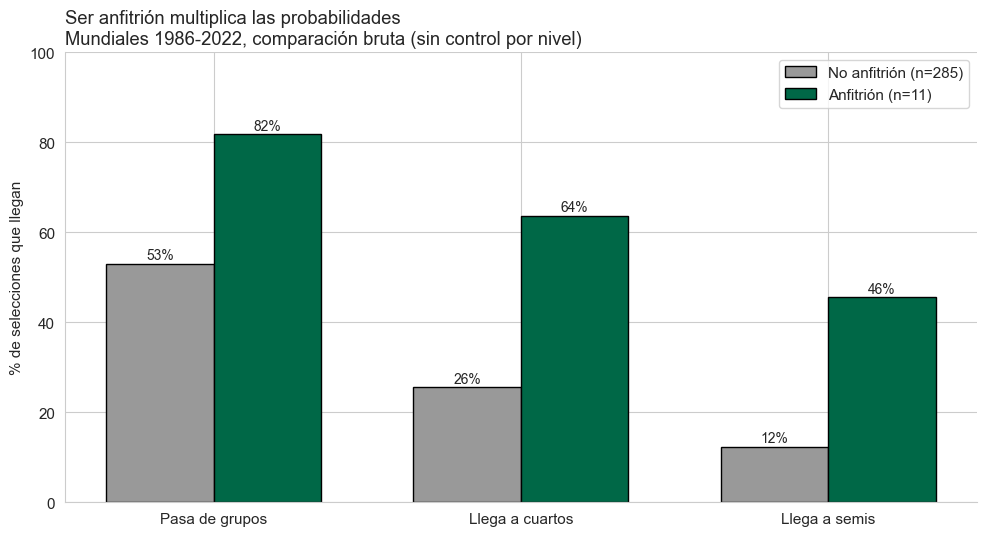

In [11]:
# Visualización: ventaja de anfitrión (cruda, sin controlar por nivel)
fig, ax = plt.subplots(figsize=(10, 5.5))

metricas = ['pct_pasa_grupos', 'pct_llega_cuartos', 'pct_llega_semis']
labels_m = ['Pasa de grupos', 'Llega a cuartos', 'Llega a semis']
x = np.arange(len(metricas))
w = 0.35

no_anf = comparacion.loc[False, metricas].values
anf = comparacion.loc[True, metricas].values

bars1 = ax.bar(x - w/2, no_anf, w, label=f'No anfitrión (n={int(comparacion.loc[False, "n"])})', color=GRIS, edgecolor='black')
bars2 = ax.bar(x + w/2, anf, w, label=f'Anfitrión (n={int(comparacion.loc[True, "n"])})', color=VERDE_MX, edgecolor='black')

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+1, f'{h:.0f}%', ha='center', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(labels_m)
ax.set_ylabel('% de selecciones que llegan')
ax.set_ylim(0, 100)
ax.set_title('Ser anfitrión multiplica las probabilidades\nMundiales 1986-2022, comparación bruta (sin control por nivel)', loc='left')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUTS / 'eda_05_anfitrion_bruto.png', dpi=120, bbox_inches='tight')
plt.show()

⚠️ **OJO con esta lectura.** Este gráfico es la comparación **bruta**, sin control. Los anfitriones suelen ser países con tradición futbolística (Brasil, Alemania, Argentina, Italia...) que ya tenían ventaja antes de jugar en casa. Para aislar el efecto puro de ser anfitrión necesitamos regresión logística controlando por ELO previo — eso lo hacemos en el notebook 05.

Pero la dirección del efecto es real, y la magnitud parece grande. Buena pista.

## 8. Resumen del notebook

Lo que aprendimos:

1. **La distribución de goles se ajusta bien a Poisson** → modelo Poisson del notebook 04 está justificado.
2. **El fútbol mete menos goles que antes** (caída de ~4 a ~2.5 por partido en 100 años) → el modelo debe tener un término temporal o filtrar por época.
3. **México es una selección de nivel medio-alto global** → no es Brasil, pero tampoco está peleando por no descender de FIFA. El "techo de octavos" no es accidente de débil; es consistente con su nivel.
4. **La ventaja de local existe en partidos oficiales** → diferencial bruto medible.
5. **Los anfitriones de Mundial llegan más lejos** → pero confundido con su nivel previo. A controlar en el notebook 05.

**Próximo notebook (03):** construir el rating ELO histórico de todas las selecciones.